In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\hp\afficionado_forecasting\data\transactions.csv')
df['transaction_time'] = pd.to_datetime(df['transaction_time'], format = '%H:%M:%S')
df['revenue'] = df['transaction_qty'] * df['unit_price']
df['hour'] = df['transaction_time'].dt.hour

#Reconstruct dates
df_sorted = df.sort_values('transaction_id').reset_index(drop=True)
df_sorted['prev_hour'] = df_sorted['hour'].shift(1).fillna(0)
df_sorted['day_change'] = (df_sorted['hour'] < df_sorted['prev_hour'] -5).astype(int)
df_sorted['day_number'] = df_sorted['day_change'].cumsum()
start_date = pd.Timestamp('2025-01-01')
df_sorted['date'] = start_date + pd.to_timedelta(df_sorted['day_number'], unit='D')

#Build daily time series
daily_ts = df_sorted.groupby(['date','store_location']).agg(
    total_revenue=('revenue','sum'),
    total_qty=('transaction_qty','sum'),
    num_transactions=('transaction_id','count')
).reset_index()

print("Daily time series ready:", daily_ts.shape)
print(daily_ts.head(6))

Daily time series ready: (543, 5)
        date   store_location  total_revenue  total_qty  num_transactions
0 2025-01-01          Astoria         868.40        277               190
1 2025-01-01   Hell's Kitchen         851.45        270               184
2 2025-01-01  Lower Manhattan         788.35        255               176
3 2025-01-02          Astoria         925.50        301               212
4 2025-01-02   Hell's Kitchen         828.80        272               195
5 2025-01-02  Lower Manhattan         649.05        217               159


In [2]:
#Add calender features
daily_ts['day_of_week'] = pd.to_datetime(daily_ts['date']).dt.dayofweek
daily_ts['is_weekend'] = (daily_ts['day_of_week'] >= 5).astype(int)
daily_ts['month'] = pd.to_datetime(daily_ts['date']).dt.month
daily_ts['week_of_year'] = pd.to_datetime(daily_ts['date']).dt.isocalendar().week.astype(int)
daily_ts['day_of_month'] = pd.to_datetime(daily_ts['date']).dt.day

print("Calender features added")
print(daily_ts[['date','store_location','day_of_week','is_weekend','month']].head(9))

Calender features added
        date   store_location  day_of_week  is_weekend  month
0 2025-01-01          Astoria            2           0      1
1 2025-01-01   Hell's Kitchen            2           0      1
2 2025-01-01  Lower Manhattan            2           0      1
3 2025-01-02          Astoria            3           0      1
4 2025-01-02   Hell's Kitchen            3           0      1
5 2025-01-02  Lower Manhattan            3           0      1
6 2025-01-03          Astoria            4           0      1
7 2025-01-03   Hell's Kitchen            4           0      1
8 2025-01-03  Lower Manhattan            4           0      1


In [4]:
#add lag features(per store, sorted by date)
daily_ts = daily_ts.sort_values(['store_location','date']).reset_index(drop=True)
daily_ts['lag_1'] = daily_ts.groupby('store_location')['total_revenue'].shift(1)
daily_ts['lag_7'] = daily_ts.groupby('store_location')['total_revenue'].shift(7)
daily_ts['lag_14'] = daily_ts.groupby('store_location')['total_revenue'].shift(14)

daily_ts['roll_7d'] = daily_ts.groupby('store_location')['total_revenue'].transform(
    lambda x: x.shift(1).rolling(7).mean())
daily_ts['roll_14d'] = daily_ts.groupby('store_location')['total_revenue'].transform(
    lambda x: x.shift(1).rolling(14).mean())
daily_ts['roll_30d'] = daily_ts.groupby('store_location')['total_revenue'].transform(
    lambda x: x.shift(1).rolling(30).mean())

print("Lag features added")
print(daily_ts[['date','store_location','total_revenue','lag_1','lag_7','roll_7d']].head(12))

Lag features added
         date store_location  total_revenue   lag_1   lag_7     roll_7d
0  2025-01-01        Astoria         868.40     NaN     NaN         NaN
1  2025-01-02        Astoria         925.50  868.40     NaN         NaN
2  2025-01-03        Astoria         902.75  925.50     NaN         NaN
3  2025-01-04        Astoria         808.25  902.75     NaN         NaN
4  2025-01-05        Astoria         903.05  808.25     NaN         NaN
5  2025-01-06        Astoria         716.05  903.05     NaN         NaN
6  2025-01-07        Astoria         807.30  716.05     NaN         NaN
7  2025-01-08        Astoria         793.15  807.30  868.40  847.328571
8  2025-01-09        Astoria         774.01  793.15  925.50  836.578571
9  2025-01-10        Astoria         947.00  774.01  902.75  814.937143
10 2025-01-11        Astoria         740.15  947.00  808.25  821.258571
11 2025-01-12        Astoria         660.70  740.15  903.05  811.530000


In [5]:
#store dummy variables
store_dummies = pd.get_dummies(daily_ts['store_location'], prefix='store')
daily_ts = pd.concat([daily_ts, store_dummies], axis=1)

daily_ts_clean = daily_ts.dropna().reset_index(drop=True)

print("Shape before dropping NaN:", daily_ts.shape)
print("Shape after dropping NaN:", daily_ts_clean.shape)
print("Rows lost:", daily_ts.shape[0] - daily_ts_clean.shape[0])
print("\nFinal columns:", daily_ts_clean.columns.tolist())

Shape before dropping NaN: (543, 19)
Shape after dropping NaN: (453, 19)
Rows lost: 90

Final columns: ['date', 'store_location', 'total_revenue', 'total_qty', 'num_transactions', 'day_of_week', 'is_weekend', 'month', 'week_of_year', 'day_of_month', 'lag_1', 'lag_7', 'lag_14', 'roll_7d', 'roll_14d', 'roll_30d', 'store_Astoria', "store_Hell's Kitchen", 'store_Lower Manhattan']


C:\Users\hp\AppData\Local\Temp\ipykernel_10792\1485568773.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Weekday', 'Weekend'])


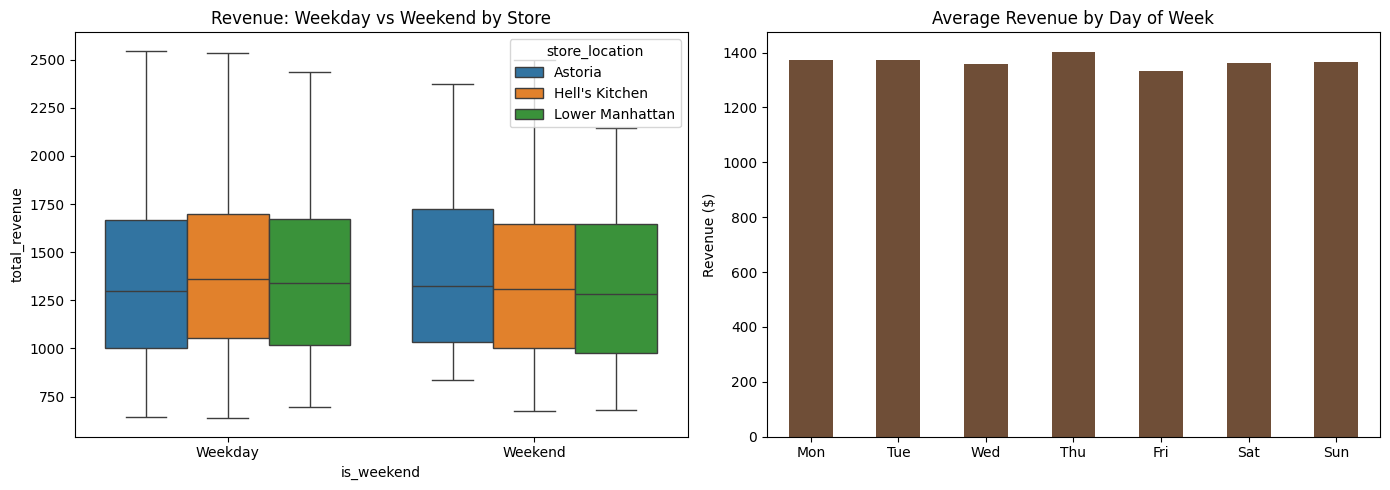

In [8]:
#visualise weekend vs weekday effect
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.boxplot(data=daily_ts_clean, x='is_weekend', y='total_revenue',
            hue='store_location', ax=axes[0])
axes[0].set_title('Revenue: Weekday vs Weekend by Store')
axes[0].set_xticklabels(['Weekday', 'Weekend'])

dow_avg = daily_ts_clean.groupby('day_of_week')['total_revenue'].mean()
dow_avg.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_avg.plot(kind='bar', ax=axes[1], color='#6F4E37')
axes[1].set_title('Average Revenue by Day of Week')
axes[1].set_ylabel('Revenue ($)')
axes[1].tick_params(axis='x', rotation = 0)

plt.tight_layout()
plt.savefig('data/feature_patterns.png')
plt.show()

In [9]:
#saving the engineered dataset for modelling
daily_ts_clean.to_csv(r'C:\Users\hp\afficionado_forecasting\data\daily_features.csv')
print("Saved! Final dataset shape:", daily_ts_clean.shape)
print("\nFeature summary:")
print(daily_ts_clean.describe().round(2))

Saved! Final dataset shape: (453, 19)

Feature summary:
                      date  total_revenue  total_qty  num_transactions  \
count                  453         453.00     453.00            453.00   
mean   2025-04-16 00:00:00        1367.48     419.97            291.97   
min    2025-01-31 00:00:00         637.60     202.00            138.00   
25%    2025-03-09 00:00:00        1020.75     311.00            214.00   
50%    2025-04-16 00:00:00        1301.45     403.00            280.00   
75%    2025-05-24 00:00:00        1679.38     518.00            361.00   
max    2025-06-30 00:00:00        2546.43     770.00            498.00   
std                    NaN         422.40     127.70             85.79   

       day_of_week  is_weekend   month  week_of_year  day_of_month    lag_1  \
count       453.00      453.00  453.00        453.00        453.00   453.00   
mean          3.02        0.29    4.01         15.85         15.62  1360.85   
min           0.00        0.00    1.00  